# Agentic NL-to-SQL Pipeline for Spatio-Temporal Check-in Analysis

This notebook is the **agentic pipeline** companion to the paper.
It keeps the same SQL generator as the naive baseline, but wraps it in a ReAct-style agent that can:
- inspect schema
- generate SQL
- execute SQL and observe failures
- read saved results
- create plots and maps
- synthesize a final answer

For code reviewers, the notebook is organized around clear tool boundaries so the reasoning loop is easy to follow.


In [ ]:
# Colab dependency setup
!pip install \
    langchain \
    openai \
    sqlalchemy \
    psycopg2-binary \
    transformers \
    accelerate \
    bitsandbytes \
    folium \
    matplotlib \
    pandas \
    torch \
    einops \
    langchain-community \
    langchain-huggingface \
    langgraph \
    langchain-openai \
    langchain-mistralai \
    langchain-google-genai

from transformers import BitsAndBytesConfig


In [ ]:
# -----------------------------
# Environment and shared resources
# -----------------------------
import ast
import datetime
import decimal
import gc
import os
import uuid

import folium
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import pandas as pd
import torch
from folium.plugins import HeatMap, MarkerCluster
from google.colab import userdata
from langchain.sql_database import SQLDatabase
from langchain_core.messages import SystemMessage
from langchain_core.tools import tool
from langgraph.prebuilt import create_react_agent
from langchain_mistralai import ChatMistralAI
from sqlalchemy import create_engine, text
from transformers import AutoModelForCausalLM, AutoTokenizer

# Secrets are intentionally pulled from Colab userdata so credentials are not hard-coded in the notebook.
DATABASE_URL = userdata.get("DATABASE_URL")
MISTRAL_API = userdata.get("MISTRAL_API")
GOOGLE_API = userdata.get("GOOGLE_API_KEY")

if not DATABASE_URL:
    raise ValueError("Missing DATABASE_URL in Colab secrets.")
if not MISTRAL_API:
    raise ValueError("Missing MISTRAL_API in Colab secrets.")

# Shared database handles used by the tools below.
db = SQLDatabase.from_uri(DATABASE_URL)
engine = create_engine(DATABASE_URL)
os.environ["MISTRAL_API_KEY"] = MISTRAL_API


In [ ]:
# -----------------------------
# SQL generator configuration
# -----------------------------
# In the paper, SQLCoder is the atomic SQL generator. The agent adds planning,
# retries, and tool use around this model rather than replacing it.
bnb_config = BitsAndBytesConfig(
    load_in_8bit=True,
    llm_int8_enable_fp32_cpu_offload=True,
    llm_int8_threshold=6.0,
    llm_int8_has_fp16_weight=True,
)

MODEL_NAME = "defog/llama-3-sqlcoder-8b"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map="auto",
    quantization_config=bnb_config,
)
model.eval()


In [ ]:
# -----------------------------
# Tool 1: schema inspection
# -----------------------------
@tool
def get_database_schema_tool() -> str:
    """Return database schema information so the agent can ground SQL generation."""
    try:
        return db.get_table_info()
    except Exception as exc:
        return f"Error fetching schema: {exc}"


In [ ]:
# -----------------------------
# Tool 2: SQL generation
# -----------------------------
def build_sql_prompt(user_question: str, database_schema: str, instructions: str = "") -> str:
    """Build the SQLCoder prompt used by the generator tool."""
    return f"""
<|begin_of_text|><|start_header_id|>user<|end_header_id|>

Generate a SQL query to answer this question: "{user_question}"
{instructions}
Do not define latitude and longitude bounds unless explicitly requested to.

DDL statements:
{database_schema}<|eot_id|><|start_header_id|>assistant<|end_header_id|>

The following SQL query best answers the question "{user_question}":
```sql
"""


@tool
def generate_sql_query_tool(user_question: str, database_schema: str, instructions: str = "") -> str:
    """Generate SQL from natural language using the baseline SQL model."""
    prompt = build_sql_prompt(user_question, database_schema, instructions)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=512,
            do_sample=False,
            temperature=0.0,
            pad_token_id=tokenizer.eos_token_id,
        )

    decoded = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    sql_only = decoded.replace(prompt, "").strip().split("```sql")[-1].split("```")[0].strip()
    return sql_only


In [ ]:
# -----------------------------
# Tool 3: SQL execution
# -----------------------------
def serialize_value(value):
    """Convert database values into JSON-safe Python values for preview and file export."""
    if isinstance(value, (datetime.datetime, datetime.date, datetime.time)):
        return value.isoformat()
    if isinstance(value, decimal.Decimal):
        return float(value)
    if isinstance(value, uuid.UUID):
        return str(value)
    return value


@tool
def execute_on_database_tool(query: str, filename: str) -> dict:
    """Execute SQL, save the full result set to disk, and return a small preview.

    The explicit error return path is important for the agentic loop: execution failures
    become observable signals that the agent can use for self-correction.
    """
    try:
        with engine.connect() as conn:
            result = conn.execute(text(query))
            rows = [dict(row._mapping) for row in result]

        safe_rows = [
            {key: serialize_value(value) for key, value in row.items()}
            for row in rows
        ]

        with open(filename, "w", encoding="utf-8") as handle:
            for row in safe_rows:
                handle.write(str(row) + "\n")

        return {
            "filename": filename,
            "row_count": len(safe_rows),
            "data_preview": safe_rows[:10],
        }
    except Exception as exc:
        error_file = filename.replace(".txt", "_error.txt")
        with open(error_file, "w", encoding="utf-8") as handle:
            handle.write(str(exc))
        return {"filename": error_file, "row_count": 0, "error": str(exc)}


In [ ]:
# -----------------------------
# Tool 4: read saved result files
# -----------------------------
@tool
def read_file_tool(file: str) -> dict:
    """Read a saved TXT result file produced by the execution tool."""
    try:
        if not os.path.exists(file):
            return {"error": f"File not found: {file}"}

        with open(file, "r", encoding="utf-8") as handle:
            lines = [line.rstrip("\n") for line in handle]
        return {"lines": lines}
    except Exception as exc:
        return {"error": f"Error reading file: {exc}"}


In [ ]:
# -----------------------------
# Tool 5: map results
# -----------------------------
@tool
def map_results_tool(data=None, file: str = None, heatmap: bool = False, name: str = "checkins_map") -> dict:
    """Create an interactive Folium map from coordinates returned by SQL."""
    try:
        if file:
            if not os.path.exists(file):
                return {"error": f"File not found: {file}"}
            with open(file, "r", encoding="utf-8") as handle:
                rows = [ast.literal_eval(line.strip()) for line in handle if line.strip()]
            df = pd.DataFrame(rows)
        elif data:
            if not isinstance(data, list) or not data:
                return {"error": "No data to plot; expected a non-empty list of dictionaries."}
            df = pd.DataFrame(data)
        else:
            return {"error": "No data provided. Pass either 'data' or 'file'."}

        if not {"latitude", "longitude"}.issubset(df.columns):
            return {"error": "Data must contain 'latitude' and 'longitude' columns."}

        df = df[df["latitude"].notna() & df["longitude"].notna()]
        if df.empty:
            return {"error": "No valid latitude/longitude rows to plot."}

        center_lat = df["latitude"].mean()
        center_lon = df["longitude"].mean()
        result_map = folium.Map(location=[center_lat, center_lon], zoom_start=12)

        has_categories = "category_name" in df.columns
        category_colors = {}
        if has_categories:
            categories = df["category_name"].dropna().unique()
            cmap = cm.get_cmap("tab10").resampled(max(len(categories), 1))
            norm = mcolors.Normalize(vmin=0, vmax=max(len(categories) - 1, 1))
            category_colors = {
                category: mcolors.to_hex(cmap(norm(i)))
                for i, category in enumerate(categories)
            }

        if heatmap:
            if has_categories:
                for category, color in category_colors.items():
                    category_df = df[df["category_name"] == category]
                    heat_data = category_df[["latitude", "longitude"]].values.tolist()
                    if heat_data:
                        HeatMap(heat_data, name=str(category), gradient={0.4: color, 1: color}).add_to(result_map)
                folium.LayerControl(collapsed=False).add_to(result_map)
            else:
                HeatMap(df[["latitude", "longitude"]].values.tolist()).add_to(result_map)
        else:
            marker_cluster = MarkerCluster().add_to(result_map)
            for _, row in df.iterrows():
                popup_parts = []
                if "category_name" in row and pd.notna(row.get("category_name")):
                    popup_parts.append(f"<b>Category:</b> {row['category_name']}")
                if "place_id" in row and pd.notna(row.get("place_id")):
                    popup_parts.append(f"<b>Place ID:</b> {row['place_id']}")
                popup_parts.append(
                    f"<b>Latitude:</b> {row['latitude']}<br><b>Longitude:</b> {row['longitude']}"
                )
                popup = "<br>".join(popup_parts)

                if has_categories and pd.notna(row.get("category_name")):
                    color = category_colors[row["category_name"]]
                    folium.CircleMarker(
                        location=[row["latitude"], row["longitude"]],
                        radius=8,
                        color=color,
                        fill=True,
                        fill_color=color,
                        fill_opacity=1.0,
                        popup=folium.Popup(popup, max_width=250),
                    ).add_to(marker_cluster)
                else:
                    folium.Marker(
                        [row["latitude"], row["longitude"]],
                        popup=folium.Popup(popup, max_width=250),
                    ).add_to(marker_cluster)

        timestamp = datetime.datetime.now(datetime.timezone.utc).strftime("%Y-%m-%d_%H-%M-%S")
        filename = f"{name}_{timestamp}.html"
        result_map.save(filename)
        return {"map_file": filename}
    except Exception as exc:
        return {"error": f"Error generating map: {exc}"}


In [ ]:
# -----------------------------
# Tool 6: plot results
# -----------------------------
@tool
def plot_results_tool(data=None, file: str = None, plot_type: str = "bar", x: str = None, y: str = None, name: str = "plot") -> dict:
    """Create a matplotlib plot from query results."""
    try:
        if file:
            if not os.path.exists(file):
                return {"error": f"File not found: {file}"}
            with open(file, "r", encoding="utf-8") as handle:
                rows = [ast.literal_eval(line.strip()) for line in handle if line.strip()]
            if len(rows) > 25:
                return {"error": f"Too many rows ({len(rows)}). Maximum allowed is 25."}
            df = pd.DataFrame(rows)
        elif data:
            if not isinstance(data, list) or not data:
                return {"error": "No data to plot; expected a non-empty list of dictionaries."}
            if len(data) > 25:
                return {"error": f"Too many rows ({len(data)}). Maximum allowed is 25."}
            df = pd.DataFrame(data)
        else:
            return {"error": "No data provided. Pass either 'data' or 'file'."}

        if plot_type in {"bar", "line"}:
            if x is None or y is None:
                return {"error": "For bar and line plots, both 'x' and 'y' are required."}
            if x not in df.columns or y not in df.columns:
                return {"error": f"Columns '{x}' or '{y}' not found in data."}

        plt.figure(figsize=(8, 6))
        if plot_type == "bar":
            plt.bar(df[x], df[y])
            plt.xlabel(x)
            plt.ylabel(y)
        elif plot_type == "line":
            plt.plot(df[x], df[y], marker="o")
            plt.xlabel(x)
            plt.ylabel(y)
        elif plot_type == "histogram":
            numeric_columns = df.select_dtypes(include="number").columns
            if y and y in df.columns:
                column = y
            elif len(numeric_columns) > 0:
                column = numeric_columns[0]
            else:
                return {"error": "Histogram requires at least one numeric column."}
            plt.hist(df[column], bins=10)
            plt.xlabel(column)
            plt.ylabel("Count")
        else:
            return {"error": f"Unsupported plot_type '{plot_type}'."}

        plt.title(f"{plot_type.capitalize()} plot")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()

        timestamp = datetime.datetime.now(datetime.timezone.utc).strftime("%Y-%m-%d_%H-%M-%S")
        filename = f"{name}_{timestamp}.png"
        plt.savefig(filename)
        plt.close()
        return {"file": filename}
    except Exception as exc:
        return {"error": f"Error generating plot: {exc}"}


In [ ]:
# -----------------------------
# Memory cleanup before agent orchestration
# -----------------------------
gc.collect()
torch.cuda.empty_cache()


In [ ]:
# -----------------------------
# ReAct agent setup
# -----------------------------
llm_mistral = ChatMistralAI(
    model="mistral-large-latest",
    temperature=0.0,
)

tools = [
    get_database_schema_tool,
    generate_sql_query_tool,
    execute_on_database_tool,
    map_results_tool,
    plot_results_tool,
    read_file_tool,
]

# The system prompt makes the intended control flow explicit for reviewers.
# It also reflects the paper's design goal: the agent reasons, acts with one tool,
# observes the result, and iterates until it can answer.
system_message = SystemMessage(
    content=(
        "You are a data assistant specialized in analyzing check-in data.\n\n"
        "=== CORE WORKFLOW (ReAct Method) ===\n"
        "- On every interaction, follow the loop: reason -> act (one tool call) -> observe -> repeat.\n"
        "- Never batch more than one tool call in a single step.\n"
        "- Break complex questions into small steps such as schema lookup, SQL generation, execution, and visualization.\n"
        "- Retry failed queries with schema-specific corrections or clearer instructions.\n\n"
        "=== REASONING GUIDELINES ===\n"
        "- Reformulate vague user requests into schema-aware language before SQL generation.\n"
        "- For region-based requests, prefer rectangular bounds rather than radius filters.\n"
        "- For time ranges crossing midnight, use: hour >= X OR hour < Y.\n"
        "- Use plots or maps when they materially improve interpretation.\n"
        "- End with a concise final answer that explains the result clearly."
    )
)

agent = create_react_agent(
    llm_mistral,
    tools,
    prompt=system_message,
)


## Example query

The cell below shows a simple end-to-end invocation.
For a GitHub version, this is a useful smoke test because it demonstrates the agent/tool contract without requiring a long benchmark script.


In [ ]:
from IPython.display import Markdown, display

query = "Make a heatmap of gyms in NYC."
final_message_content = ""

for chunk in agent.stream(
    {"messages": [("human", query)]},
    stream_mode="updates",
    recursion_limit=50,
):
    print(chunk)
    print("\n")
    if "agent" in chunk and chunk["agent"]["messages"]:
        last_message = chunk["agent"]["messages"][-1]
        if hasattr(last_message, "content"):
            final_message_content = last_message.content

if final_message_content:
    display(Markdown(final_message_content))

print(f"Query: {query}")


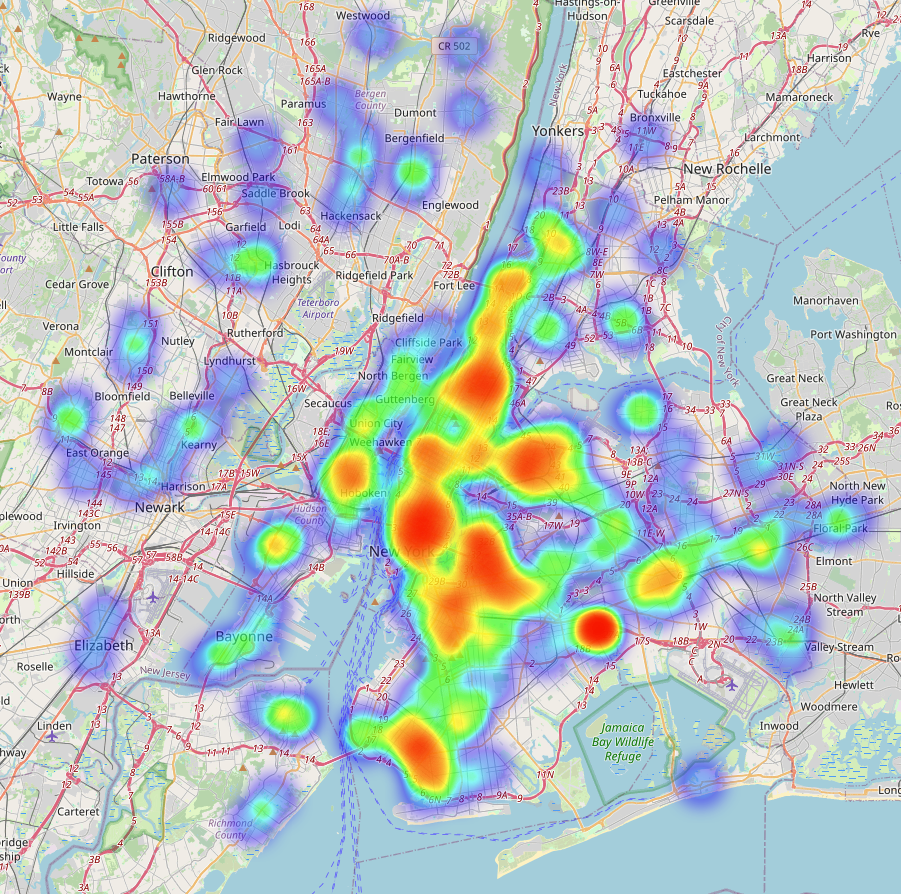

In [1]:
from IPython.display import Image
Image('map_example.png')